The focus of this research is to look into the evolution of Radiohead's toruing patterns over time and what this reveals about their rise to global popularity.

In [3]:
import requests

api_key = "ll7RGzF_XpmvVKwb6S4Ok66BeVqrM1NblZqK"
url = "https://api.setlist.fm/rest/1.0/search/setlists?artistMbid=a74b1b7f-71a5-4011-9441-d0b5e4122711&p=1"

headers = {
    "x-api-key": api_key,
    "Accept": "application/json"
}

response = requests.get(url, headers=headers)

In [4]:
response

<Response [200]>

In [5]:
data = response.json()


In [ ]:
data = response.json()

Here is how I retrieved a list of their first shows.

In [ ]:
import pandas as pd
import requests

rows = []

for page in range(1, 200):
    data = requests.get(
        f"https://api.setlist.fm/rest/1.0/search/setlists?artistMbid=a74b1b7f-71a5-4011-9441-d0b5e4122711&p={page}",
        headers=headers
    ).json()

    if "setlist" not in data:
        break

    for show in data["setlist"]:
        date = show["eventDate"]
        venue = show["venue"]["name"]
        city = show["venue"]["city"]["name"]
        country = show["venue"]["city"]["country"]["name"]

        for s in show.get("sets", {}).get("set", []):
            for song in s.get("song", []):
                rows.append({
                    "date":     date,
                    "venue":    venue,
                    "city":     city,
                    "country":  country,
                    "song":     song["name"],
                    "tour":     show.get("tour", {}).get("name", "Unknown"),
                    "position": song.get("order", 0),
                    "is_cover": song.get("cover") is not None,
                    "is_tape":  song.get("tape", False),
                })

    if page >= -(-data["total"] // data["itemsPerPage"]):
        break

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")
df["year"] = df["date"].dt.year
df["large_venue"] = df["venue"].str.contains("Arena|Stadium|Amphitheatre|Dome|Theater", case=False)
df["decade"] = (df["year"] // 10 * 10)
df["month"] = df["date"].dt.month

df.sort_values("date").head()

,date,venue,city,country,song,tour,position,is_cover,is_tape,year,large_venue,decade,month
14437,1995-03-13,Wulfrun Hall,Wolverhampton,United Kingdom,Ripcord,The Bends,0,False,False,1995,False,1990,3
14418,1995-03-13,Wulfrun Hall,Wolverhampton,United Kingdom,The Bends,The Bends,0,False,False,1995,False,1990,3
14419,1995-03-13,Wulfrun Hall,Wolverhampton,United Kingdom,Just,The Bends,0,False,False,1995,False,1990,3
14420,1995-03-13,Wulfrun Hall,Wolverhampton,United Kingdom,Anyone Can Play Guitar,The Bends,0,False,False,1995,False,1990,3
14421,1995-03-13,Wulfrun Hall,Wolverhampton,United Kingdom,Bones,The Bends,0,False,False,1995,False,1990,3


This is a list of the top songs they've played throughout the years and how many times they've played them.

In [ ]:
df["song"].value_counts().head(10)

,count
song,
Paranoid Android,471
Street Spirit (Fade Out),448
Lucky,431
Fake Plastic Trees,412
Everything in Its Right Place,398
My Iron Lung,394
Idioteque,386
Just,381
Karma Police,359


In [ ]:
print(len(df))
print(df["date"].min())
print(df["date"].max())

14438
1995-03-13 00:00:00
2025-12-16 00:00:00


Here's how I found their five Most Recent Shows.

In [ ]:
import pandas as pd

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")

df.head()

,date,venue,city,country,song,tour,position,is_cover,is_tape
0,2025-12-16,Royal Arena,Copenhagen,Denmark,2 + 2 = 5,European Tour 2025,0,False,False
1,2025-12-16,Royal Arena,Copenhagen,Denmark,Airbag,European Tour 2025,0,False,False
2,2025-12-16,Royal Arena,Copenhagen,Denmark,The Bends,European Tour 2025,0,False,False
3,2025-12-16,Royal Arena,Copenhagen,Denmark,All I Need,European Tour 2025,0,False,False
4,2025-12-16,Royal Arena,Copenhagen,Denmark,Ful Stop,European Tour 2025,0,False,False


These are the amount of shows they have played per year.

In [ ]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

shows_per_year = df.drop_duplicates(subset=["date","venue"]).groupby("year").size()

shows_per_year


,0
year,
1995,129
1996,50
1997,84
1998,35
1999,2
2000,46
2001,36
2002,12
2003,78


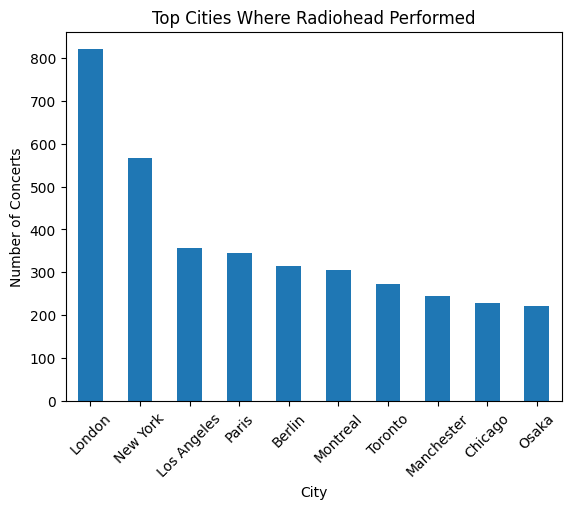

In [ ]:
import matplotlib.pyplot as plt
top_cities = df["city"].value_counts().head(10)

top_cities.plot(kind="bar")
plt.title("Top Cities Where Radiohead Performed")
plt.xlabel("City")
plt.ylabel("Number of Concerts")
plt.xticks(rotation=45)
plt.show()

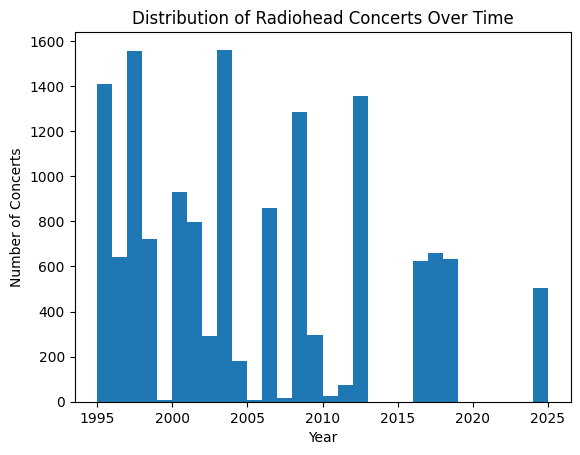

In [ ]:
plt.hist(df["year"], bins=30)
plt.title("Distribution of Radiohead Concerts Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Concerts")
plt.show()

Number of Venues They've Played

In [ ]:
df["venue"].nunique()

503

Here are the cities they've played in and how many times they've played there.

It seems that Radiohead's breakout year was 1995 following the release of The Bends

In [ ]:
large_words = ["Arena", "Stadium", "Amphitheatre", "Amphitheater", "Coliseum", "Dome", "Theater"]

df["large_venue"] = df["venue"].str.contains("|".join(large_words), case=False)

df[df["large_venue"]].drop_duplicates(subset=["date", "venue"]).sort_values("date").head(10)

,date,venue,city,country,song,tour,position,is_cover,is_tape,year,large_venue
13842,1995-07-15,Nile Theater,Mesa,United States,My Iron Lung,The Bends,0,False,False,1995,True
13708,1995-08-09,Ramat Gan Stadium,Ramat Gan,Israel,The Bends,The Bends,0,False,False,1995,True
13681,1995-08-26,Domein Kiewit,Hasselt,Belgium,My Iron Lung,The Bends,0,False,False,1995,True
13647,1995-09-08,Miami Arena,Miami,United States,My Iron Lung,The Bends,0,False,False,1995,True
13640,1995-09-09,ThunderDome,St. Petersburg,United States,My Iron Lung,The Bends,0,False,False,1995,True
13636,1995-09-11,Starwood Amphitheatre,Antioch,United States,The Bends,The Bends,0,False,False,1995,True
13627,1995-09-12,Birmingham-Jefferson Civic Center Coliseum,Birmingham,United States,The Bends,The Bends,0,False,False,1995,True
13590,1995-09-19,Reunion Arena,Dallas,United States,Planet Telex,The Bends,0,False,False,1995,True
13582,1995-09-20,Coca-Cola Starplex Amphitheatre,Dallas,United States,The Bends,The Bends,0,False,False,1995,True
13574,1995-09-22,Riverport Amphitheatre,Maryland Heights,United States,The Bends,The Bends,0,False,False,1995,True


Though they played big venues in 1992-1993, 1995 was Radiohead's Breakout Year, thats when they started consistently playing in arenas and bigger venues.

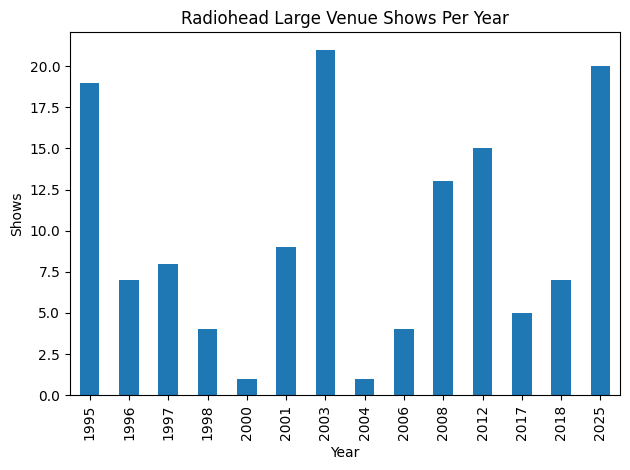

In [ ]:
large_shows_by_year = df[df["large_venue"]].drop_duplicates(subset=["date","venue"]).groupby("year").size()

large_shows_by_year.plot(kind="bar", title="Radiohead Large Venue Shows Per Year", xlabel="Year", ylabel="Shows")
plt.tight_layout()
plt.show()

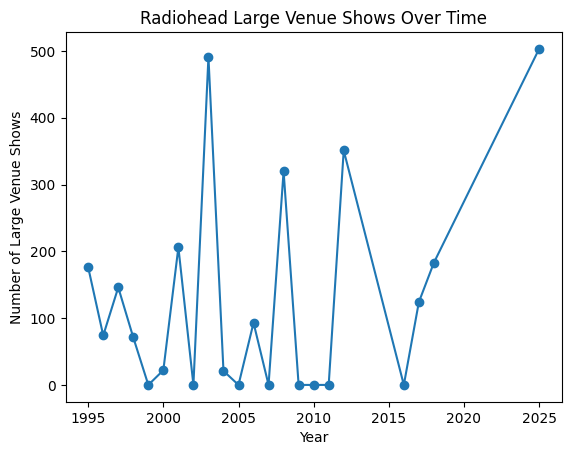

In [ ]:
large_per_year = df.groupby("year")["large_venue"].sum()

large_per_year.plot(kind="line", marker="o")
plt.title("Radiohead Large Venue Shows Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Large Venue Shows")
plt.show()


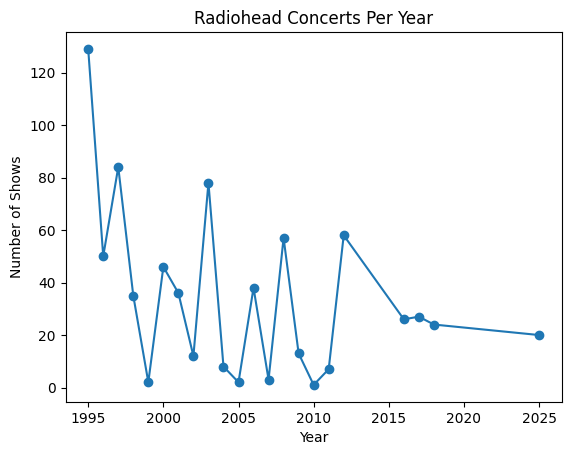

In [ ]:
import matplotlib.pyplot as plt

shows_per_year.plot(kind="line", marker="o")

plt.title("Radiohead Concerts Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Shows")
plt.show()



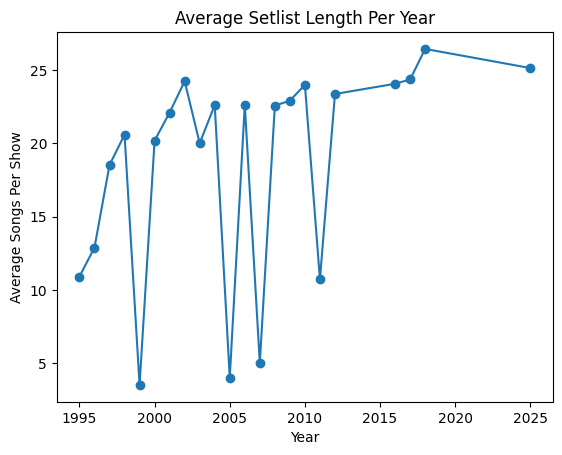

In [ ]:
# Calculate song count for each unique show
songs_per_show = df.groupby(['date', 'venue']).size().reset_index(name='song_count')

# Add the 'year' column to this new DataFrame
songs_per_show['year'] = songs_per_show['date'].dt.year

# Calculate the average songs per year
avg_songs = songs_per_show.groupby("year")["song_count"].mean()

avg_songs.plot(kind="line", marker="o")

plt.title("Average Setlist Length Per Year")
plt.xlabel("Year")
plt.ylabel("Average Songs Per Show")
plt.show()

In [ ]:
!pip install plotly


In [ ]:
import plotly.express as px

fig = px.scatter_geo(
    df_clean,
    locations="country",
    locationmode="country names",
    hover_name="city",
    animation_frame="year",
    title="Radiohead World Tour Expansion Over Time"
)

fig.show()
